# Sérsic modelling of BCG and ICL components from IFU data

In [ ]:
import astrophot as ap
import numpy as np
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.io import fits

In [ ]:
# If GPU is not available
# ap.AP_config.ap_device = "cpu"

In [ ]:
path = Path("~/data/ifu/2025-07-24/").expanduser()

In [ ]:
def plot_data_model_residual(
    target, model, mask, limits=(200, 480, 100, 275), weight=True
):
    data = target.data.cpu()
    model = model()
    model_image = model.data.cpu()
    model_image_binned = model.unbinned_data.cpu()
    if weight:
        weight_image = target.weight.cpu()
    model_image = model_image.detach().cpu().numpy()
    ncol = 5 if weight else 4
    fig, ax = plt.subplots(
        1, ncol, figsize=(3 * ncol, 4), sharex=True, sharey=True, layout="compressed"
    )
    vmax = 0.5 * np.nanmax(data)
    vmin = -0.5 * vmax
    ax[0].imshow(np.where(mask, np.nan, data), origin="lower", vmin=vmin, vmax=vmax)
    ax[1].imshow(model_image, origin="lower", vmin=vmin, vmax=vmax)
    ax[2].imshow(model_image_binned, origin="lower", vmin=vmin, vmax=vmax)
    ax[3].imshow(
        np.where(mask, np.nan, data - model_image_binned),
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )
    if weight:
        ax[4].imshow(weight_image, origin="lower")
    if limits is not None:
        ax[0].axis(limits)
    for a in ax:
        a.axvline(320.6, color="white", lw=0.5)
        a.axhline(181.1, color="white", lw=0.5)

In [ ]:
def get_data(filename):
    data = np.load(path / filename)
    return data


bins = np.load(path / "voronoi_mask_SN_4.npy")
bcg_data = get_data("BCG_SB_map.npy")
icl_data = get_data("ICL_SB_map.npy")
snr_data = get_data("SNR_map.npy")

In [ ]:
output_path = path / "outputs/"
output_path.mkdir(exist_ok=True)
fits.writeto(output_path / "bcg_data.fits", bcg_data, overwrite=True)
fits.writeto(output_path / "icl_data.fits", icl_data, overwrite=True)

In [ ]:
bcg_mask = ~np.isfinite(bcg_data)
icl_mask = ~np.isfinite(icl_data)

In [ ]:
cm = mpl.cm.Dark2
seg_cmap = mpl.colors.ListedColormap(
    np.tile(cm.colors, (int(np.ceil(np.nanmax(bins) / cm.N)), 1))
)

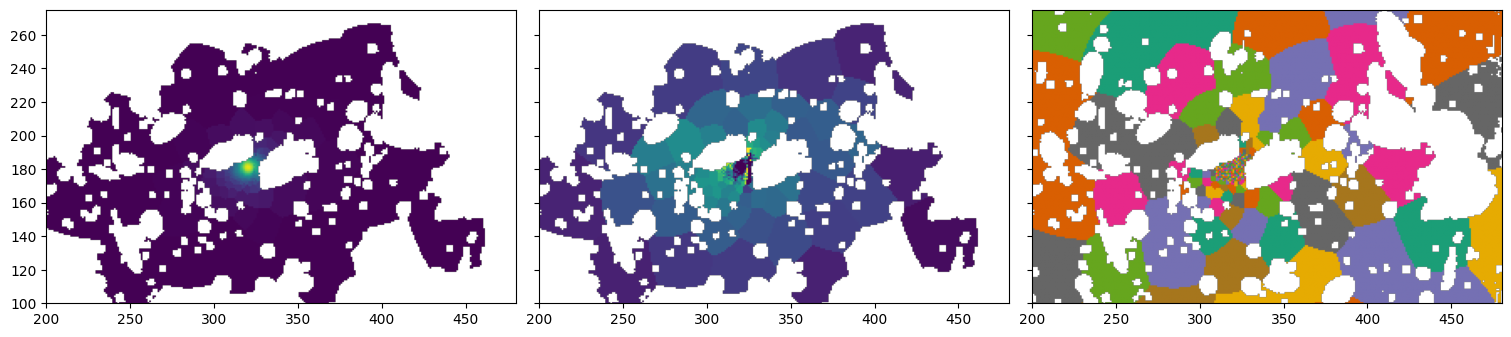

In [ ]:
fig, ax = plt.subplots(
    1, 3, figsize=(15, 5), sharex=True, sharey=True, layout="compressed"
)
ax[0].imshow(bcg_data, origin="lower", vmin=0, vmax=30)
ax[1].imshow(icl_data, origin="lower", vmin=0, vmax=3)
bins
ax[2].imshow(bins, origin="lower", cmap=seg_cmap)
ax[0].axis((200, 480, 100, 275));

In [ ]:
bcg_initial_params = {
    "center": [320, 180],
    "q": 0.6,
    "PA": 90 * np.pi / 180,
    "n": 2.0,
    "Re": 5.0,
    "Ie": 1.0,
}

## Binned fit with weights from component fraction

### Test

In [ ]:
test_params = {
    "center": [319, 179],
    "q": 0.7,
    "PA": 90 * np.pi / 180,
    "n": 1.2,
    "Re": 40.0,
    "Ie": 0.5,
}

In [ ]:
test_target = ap.image.Target_Image(
    data=np.zeros_like(bcg_data), mask=bcg_mask, bins=bins, pixelscale=1
)
test_model = ap.models.AstroPhot_Model(
    name="test_truth",
    model_type="sersic galaxy model",
    parameters=test_params,
    target=test_target,
)
test_model.initialize()

In [ ]:
test_data = test_model.sample().data.cpu()
test_noise = np.random.normal(size=test_data.shape)
test_data += test_noise

In [ ]:
test_target = ap.image.Target_Image(
    data=test_data, mask=bcg_mask, bins=bins, pixelscale=1
)
test_data_binned = test_target.unbinned_data.cpu()
test_target = ap.image.Target_Image(
    data=test_data_binned, mask=bcg_mask, bins=bins, pixelscale=1
)

In [ ]:
test_fit_model = ap.models.AstroPhot_Model(
    name="test_fit",
    model_type="sersic galaxy model",
    parameters=bcg_initial_params,
    target=test_target,
)
test_fit_model.initialize()

In [ ]:
test_result = ap.fit.LM(test_fit_model).fit()
test_result.update_uncertainty()

In [ ]:
print(test_fit_model.parameters)
print(test_model.parameters)

test_fit:
center: [319.10667370288314, 178.9760735411357] +- [0.09760500163157904, 0.06918237095484135] [arcsec]
q: 0.7214731676417674 +- 0.021767018197887976 [b/a], limits: (0.0, 1.0)
PA: 1.632881625530341 +- 0.041261015029364544 [radians], limits: (0.0, 3.141592653589793), cyclic
n: 1.183726571843002 +- 0.043429205849641786 [none], limits: (0.36, 8.0)
Re: 38.921530165536716 +- 2.705817271971602 [arcsec], limits: (0.0, None)
Ie: 0.5101591393251782 +- 0.0298728798435754 [log10(flux/arcsec^2)]
test_truth:
center: [319.0, 179.0] +- [0.1, 0.1] [arcsec]
q: 0.7 +- 0.03 [b/a], limits: (0.0, 1.0)
PA: 1.5707963267948966 +- 0.06 [radians], limits: (0.0, 3.141592653589793), cyclic
n: 1.2 +- 0.05 [none], limits: (0.36, 8.0)
Re: 40.0 [arcsec], limits: (0.0, None)
Ie: 0.5 [log10(flux/arcsec^2)]


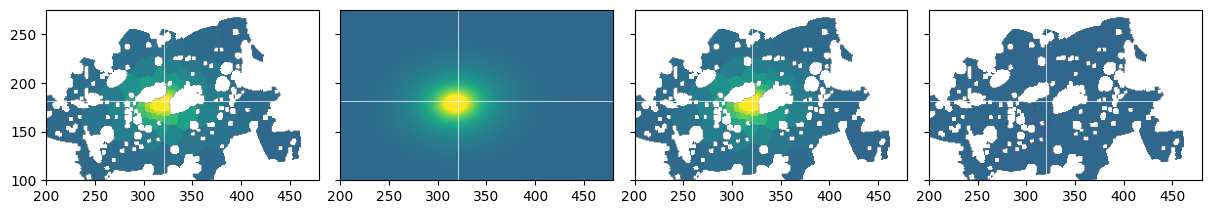

In [ ]:
plot_data_model_residual(
    test_target,
    test_fit_model,
    bcg_mask,
    weight=False,
)

### Fit the BCG

In [ ]:
total = bcg_data + icl_data
bcg_weight = bcg_data / total
bcg_weight = np.clip(bcg_weight, 1e-6, 1 - 1e-6)
icl_weight = 1 - bcg_weight

# Scale weight to reflect expected variance
total_noise = total / snr_data
total_weight = 1 / total_noise**2
bcg_weight *= total_weight
icl_weight *= total_weight

In [ ]:
bcg_target = ap.image.Target_Image(
    data=bcg_data, mask=bcg_mask, weight=bcg_weight, bins=bins, pixelscale=1
)

In [ ]:
# check binning is correct
diff = bcg_target.unbinned_data.cpu() - bcg_target.data.cpu()
diff = diff[diff.isfinite()]
np.allclose(diff, 0)

True

In [ ]:
bcg_model = ap.models.AstroPhot_Model(
    name="bcg",
    model_type="sersic galaxy model",
    parameters=bcg_initial_params,
    target=bcg_target,
)
bcg_model.initialize()

In [ ]:
bcg_result = ap.fit.LM(bcg_model).fit()
bcg_result.update_uncertainty()

In [ ]:
bcg_model.parameters

bcg (id-139951953111824, branch node):
  center (id-139951953100928): [321.0887833163136, 181.41553557482803] +- [0.0065109315720320105, 0.004853306624101469] [arcsec]
  q (id-139953809047728): 0.8144961244074427 +- 0.001134436410139658 [b/a], limits: (0.0, 1.0)
  PA (id-139951953339328): 1.6444319442545363 +- 0.0031990999640748034 [radians], limits: (0.0, 3.141592653589793), cyclic
  n (id-139953808678288): 1.2944606445076803 +- 0.002309339193903814 [none], limits: (0.36, 8.0)
  Re (id-139953809014560): 16.071444787934354 +- 0.023031615555348023 [arcsec], limits: (0.0, None)
  Ie (id-139953808826416): 0.6535247925520037 +- 0.0010560948629057027 [log10(flux/arcsec^2)]

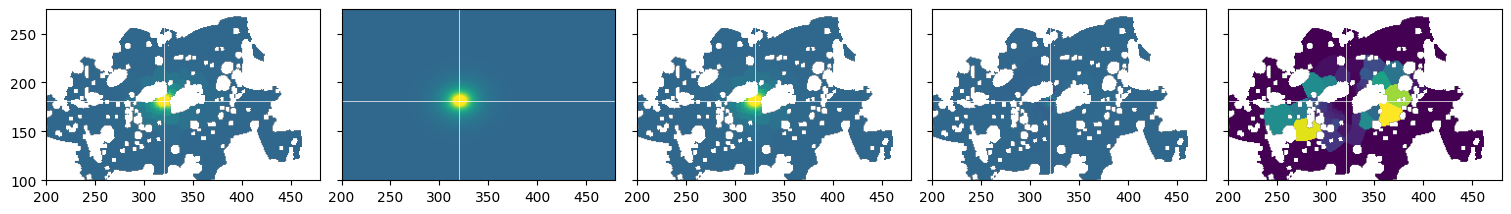

In [ ]:
plot_data_model_residual(bcg_target, bcg_model, bcg_mask)

### Fit the ICL

In [ ]:
icl_target = ap.image.Target_Image(
    data=icl_data, mask=icl_mask, weight=icl_weight, bins=bins, pixelscale=1
)

In [ ]:
def fit_icl(fixed_centre=None):
    icl_initial_params = {
        "center": [320, 180],
        "q": 0.6,
        "PA": 90 * np.pi / 180,
        "n": 2.0,
        "Re": 20.0,
        "Ie": 0.5,
    }

    if fixed_centre is not None:
        icl_initial_params.update(
            {
                "center": {
                    "value": fixed_centre.parameters["center"].value,
                    "locked": True,
                }
            }
        )

    icl_model = ap.models.AstroPhot_Model(
        name="icl",
        model_type="sersic galaxy model",
        parameters=icl_initial_params,
        target=icl_target,
    )
    icl_model.initialize()

    icl_result = ap.fit.LM(icl_model).fit()
    icl_result.update_uncertainty()

    plot_data_model_residual(
        icl_target,
        icl_model,
        icl_mask,
    )
    return icl_model

icl (id-139951952512496, branch node):
  center (id-139951952185584): [316.4032478834041, 183.72273265041667] +- [0.04147340771299349, 0.032612107900456225] [arcsec]
  q (id-139951951396112): 0.6916738358249147 +- 0.0008594916284473753 [b/a], limits: (0.0, 1.0)
  PA (id-139951954081456): 1.7782627007031475 +- 0.0013485743664716375 [radians], limits: (0.0, 3.141592653589793), cyclic
  n (id-139951953239344): 0.6679211516888459 +- 0.002226515479849528 [none], limits: (0.36, 8.0)
  Re (id-139951951395728): 71.67907317678956 +- 0.07268294163848901 [arcsec], limits: (0.0, None)
  Ie (id-139951952525408): -0.16646831723500022 +- 0.000852003953638104 [log10(flux/arcsec^2)]

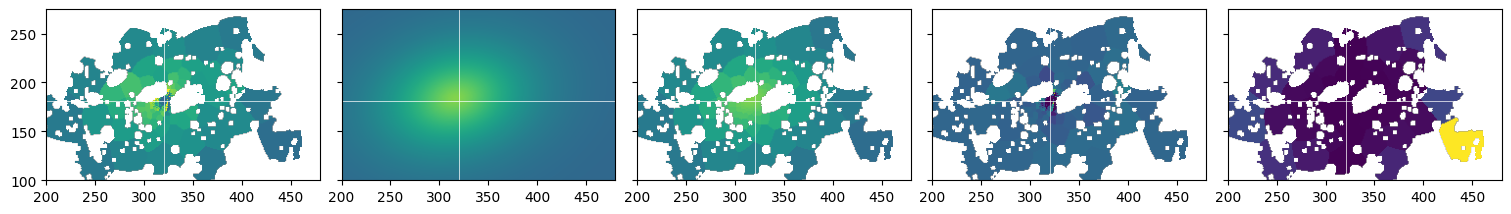

In [ ]:
icl_model = fit_icl()
icl_model.parameters

### Save the model

In [ ]:
with open(path / "bcg_model.pkl", "wb") as f:
    pickle.dump(bcg_model, f)
with open(path / "icl_model.pkl", "wb") as f:
    pickle.dump(icl_model, f)

NameError: name 'icl_model' is not defined